
# Exercise: Semantic Segmentation with U-Net on Oxford-IIIT Pet Dataset

This notebook demonstrates how to **train, validate, and evaluate a U-Net model**
for **semantic segmentation** using the **Oxford-IIIT Pet Dataset**.    

This nodebook is inspired from:
https://colab.research.google.com/github/margaretmz/image-segmentation/blob/main/unet_pet_segmentation.ipynb#scrollTo=5M_beaaBpjNP

## Learning objectives
- Understand semantic segmentation and pixel-wise classification
- Train a U-Net using Keras / TensorFlow
- Evaluate segmentation performance
- Visualize predictions


## 1. Import dependencies

In [48]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
from tensorflow.keras.layers import *
from tensorflow.keras import layers
from tensorflow.keras.models import Model


## 2. Load Oxford-IIIT Pet Dataset

In [2]:
dataset, info = tfds.load('oxford_iiit_pet:4.*.*',with_info=True)

print(info)

tfds.core.DatasetInfo(
    name='oxford_iiit_pet',
    full_name='oxford_iiit_pet/4.0.0',
    description="""
    The Oxford-IIIT pet dataset is a 37 category pet image dataset with roughly 200
    images for each class. The images have large variations in scale, pose and
    lighting. All images have an associated ground truth annotation of breed and
    species. Additionally, head bounding boxes are provided for the training split,
    allowing using this dataset for simple object detection tasks. In the test
    split, the bounding boxes are empty.
    """,
    homepage='http://www.robots.ox.ac.uk/~vgg/data/pets/',
    data_dir='/home/swmal19f26/tensorflow_datasets/oxford_iiit_pet/4.0.0',
    file_format=tfrecord,
    download_size=773.52 MiB,
    dataset_size=773.68 MiB,
    features=FeaturesDict({
        'file_name': Text(shape=(), dtype=string),
        'head_bbox': BBoxFeature(shape=(4,), dtype=float32),
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label

2026-04-28 09:18:21.983652: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-28 09:18:21.984935: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-28 09:18:21.986167: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

## 3. Preprocessing

In [3]:
IMG_SIZE = 128
NUM_CLASSES = 3  # background, pet, border

In [4]:
def resize(input_image, input_mask):
    input_image = tf.image.resize(input_image, (IMG_SIZE, IMG_SIZE), method="nearest")
    input_mask = tf.image.resize(input_mask, (IMG_SIZE, IMG_SIZE), method="nearest")

    return input_image, input_mask 

def augment(input_image, input_mask):
    if tf.random.uniform(()) > 0.5:
        # Random flipping of the image and mask
        input_image = tf.image.flip_left_right(input_image)
        input_mask = tf.image.flip_left_right(input_mask)

    return input_image, input_mask

def normalize(input_image, input_mask):
    input_image = tf.cast(input_image, tf.float32) / 255.0
    input_mask -= 1
  
    return input_image, input_mask

In [5]:
def load_image_train(datapoint):
    input_image = datapoint["image"]
    input_mask = datapoint["segmentation_mask"]
    input_image, input_mask = resize(input_image, input_mask)
    input_image, input_mask = augment(input_image, input_mask)
    input_image, input_mask = normalize(input_image, input_mask)

    return input_image, input_mask

def load_image_test(datapoint):
    input_image = datapoint["image"]
    input_mask = datapoint["segmentation_mask"]
    input_image, input_mask = resize(input_image, input_mask)
    input_image, input_mask = normalize(input_image, input_mask)

    return input_image, input_mask

In [6]:
train_dataset = dataset["train"].map(load_image_train, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = dataset["test"].map(load_image_test, num_parallel_calls=tf.data.AUTOTUNE)

print(train_dataset)

<_ParallelMapDataset element_spec=(TensorSpec(shape=(128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(128, 128, 1), dtype=tf.uint8, name=None))>


## 4. Creating train and test batches

In [7]:
BATCH_SIZE = 16
BUFFER_SIZE = 1000

In [8]:
train_batches = train_dataset.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()
train_batches = train_batches.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
validation_batches = test_dataset.take(3000).batch(BATCH_SIZE)
test_batches = test_dataset.skip(3000).take(669).batch(BATCH_SIZE)

print(train_batches)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 128, 128, 1), dtype=tf.uint8, name=None))>


## 5. Visualize dataset

In [9]:
def display(display_list):
  plt.figure(figsize=(10, 10))

  title = ["Input Image", "True Mask", "Predicted Mask"]

  for i in range(len(display_list)):
    plt.subplot(1, len(display_list), i+1)
    plt.title(title[i])
    plt.imshow(tf.keras.utils.array_to_img(display_list[i]))
    plt.axis("off")
  plt.show()

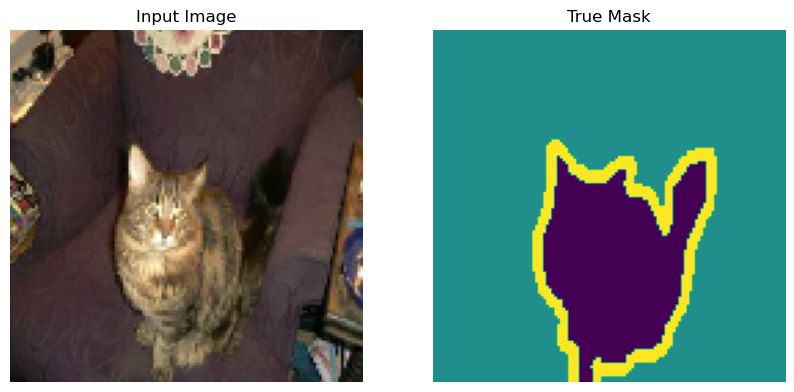

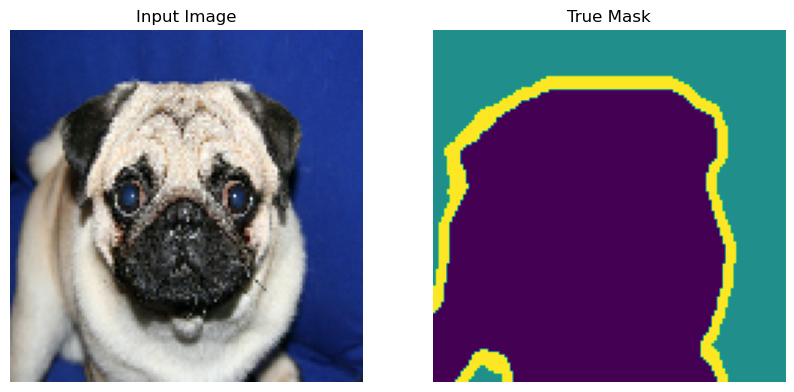

In [10]:
sample_batch = next(iter(test_batches))

for _ in range(2):
    random_index = np.random.choice(sample_batch[0].shape[0])
    sample_image, sample_mask = sample_batch[0][random_index], sample_batch[1][random_index]
    display([sample_image, sample_mask])


## 6. Create Simple U-Net Model

In [11]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Conv2DTranspose, Concatenate, Input

def simple_unet(input_shape=(IMG_SIZE,IMG_SIZE,3), num_classes=NUM_CLASSES):
    inputs = Input(input_shape)

    c1 = Conv2D(32, 3, activation='relu', padding='same')(inputs)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(64, 3, activation='relu', padding='same')(p1)
    p2 = MaxPooling2D()(c2)

    b = Conv2D(128, 3, activation='relu', padding='same')(p2)

    u2 = Conv2DTranspose(64, 2, strides=2, padding='same')(b)
    u2 = Concatenate()([u2, c2])

    u1 = Conv2DTranspose(32, 2, strides=2, padding='same')(u2)
    u1 = Concatenate()([u1, c1])

    outputs = Conv2D(num_classes, 1, activation='softmax')(u1)

    return Model(inputs, outputs)

model_simple = simple_unet()

model_simple.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_simple.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 128, 128, 32)         896       ['input_1[0][0]']             
                                                                                                  
 max_pooling2d (MaxPooling2  (None, 64, 64, 32)           0         ['conv2d[0][0]']              
 D)                                                                                               
                                                                                                  
 conv2d_1 (Conv2D)           (None, 64, 64, 64)           18496     ['max_pooling2d[0][0]']   

## 7. Create Large U-Net Model

In [12]:
def double_conv_block(x, n_filters):

    # Conv2D then ReLU activation
    x = layers.Conv2D(n_filters, 3, padding = "same", activation = "relu", kernel_initializer = "he_normal")(x)
    # Conv2D then ReLU activation
    x = layers.Conv2D(n_filters, 3, padding = "same", activation = "relu", kernel_initializer = "he_normal")(x)

    return x
    
def downsample_block(x, n_filters):
    f = double_conv_block(x, n_filters)
    p = layers.MaxPool2D(2)(f)
    p = layers.Dropout(0.3)(p)

    return f, p

def upsample_block(x, conv_features, n_filters):
    # upsample
    x = layers.Conv2DTranspose(n_filters, 3, 2, padding="same")(x)
    # concatenate 
    x = layers.concatenate([x, conv_features])
    # dropout
    x = layers.Dropout(0.3)(x)
    # Conv2D twice with ReLU activation
    x = double_conv_block(x, n_filters)

    return x

In [13]:
def build_unet_model():

    # inputs
    inputs = layers.Input(shape=(IMG_SIZE,IMG_SIZE,NUM_CLASSES))

    # encoder: contracting path - downsample
    # 1 - downsample
    f1, p1 = downsample_block(inputs, 64)
    # 2 - downsample
    f2, p2 = downsample_block(p1, 128)
    # 3 - downsample
    f3, p3 = downsample_block(p2, 256)
    # 4 - downsample
    f4, p4 = downsample_block(p3, 512)

    # 5 - bottleneck
    bottleneck = double_conv_block(p4, 1024)

    # decoder: expanding path - upsample
    # 6 - upsample
    u6 = upsample_block(bottleneck, f4, 512)
    # 7 - upsample
    u7 = upsample_block(u6, f3, 256)
    # 8 - upsample
    u8 = upsample_block(u7, f2, 128)
    # 9 - upsample
    u9 = upsample_block(u8, f1, 64)

    # outputs
    outputs = layers.Conv2D(3, 1, padding="same", activation = "softmax")(u9)

    # unet model with Keras Functional API
    unet_model = Model(inputs, outputs, name="U-Net")

    return unet_model

In [14]:
unet_model = build_unet_model()

unet_model.compile(optimizer=tf.keras.optimizers.Adam(),
                   loss="sparse_categorical_crossentropy",
                   metrics=["accuracy"])

unet_model.summary()

Model: "U-Net"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 conv2d_4 (Conv2D)           (None, 128, 128, 64)         1792      ['input_2[0][0]']             
                                                                                                  
 conv2d_5 (Conv2D)           (None, 128, 128, 64)         36928     ['conv2d_4[0][0]']            
                                                                                                  
 max_pooling2d_2 (MaxPoolin  (None, 64, 64, 64)           0         ['conv2d_5[0][0]']            
 g2D)                                                                                         

## 8. Train the U-Net Model

In [15]:
NUM_EPOCHS = 20

TRAIN_LENGTH = info.splits["train"].num_examples
STEPS_PER_EPOCH = TRAIN_LENGTH // BATCH_SIZE

VAL_SUBSPLITS = 5
TEST_LENTH = info.splits["test"].num_examples
VALIDATION_STEPS = TEST_LENTH // BATCH_SIZE // VAL_SUBSPLITS

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
]

# Comment line to use large U-Net model
unet_model = model_simple

history = unet_model.fit(
    train_batches,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    validation_data=validation_batches,
    epochs=NUM_EPOCHS,
    callbacks=callbacks
)


Epoch 1/20


2026-04-28 09:18:24.766228: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8800
2026-04-28 09:18:26.568114: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fdd869c8930 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-28 09:18:26.568145: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-04-28 09:18:26.568150: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-04-28 09:18:26.571689: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777360706.627417  312456 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


230/230 [==============================] - 8s 15ms/step - loss: 0.8394 - accuracy: 0.6052 - val_loss: 0.7662 - val_accuracy: 0.6619
Epoch 2/20
230/230 [==============================] - 3s 14ms/step - loss: 0.7243 - accuracy: 0.6764 - val_loss: 0.6994 - val_accuracy: 0.6943
Epoch 3/20
230/230 [==============================] - 3s 13ms/step - loss: 0.6734 - accuracy: 0.7075 - val_loss: 0.6713 - val_accuracy: 0.7060
Epoch 4/20
230/230 [==============================] - 3s 14ms/step - loss: 0.6514 - accuracy: 0.7203 - val_loss: 0.6540 - val_accuracy: 0.7215
Epoch 5/20
230/230 [==============================] - 3s 14ms/step - loss: 0.6319 - accuracy: 0.7308 - val_loss: 0.6284 - val_accuracy: 0.7384
Epoch 6/20
230/230 [==============================] - 3s 14ms/step - loss: 0.6153 - accuracy: 0.7392 - val_loss: 0.6081 - val_accuracy: 0.7463
Epoch 7/20
230/230 [==============================] - 3s 14ms/step - loss: 0.6087 - accuracy: 0.7427 - val_loss: 0.6094 - val_accuracy: 0.7472
Epoch 8/20

## 9. Plot Training Curves

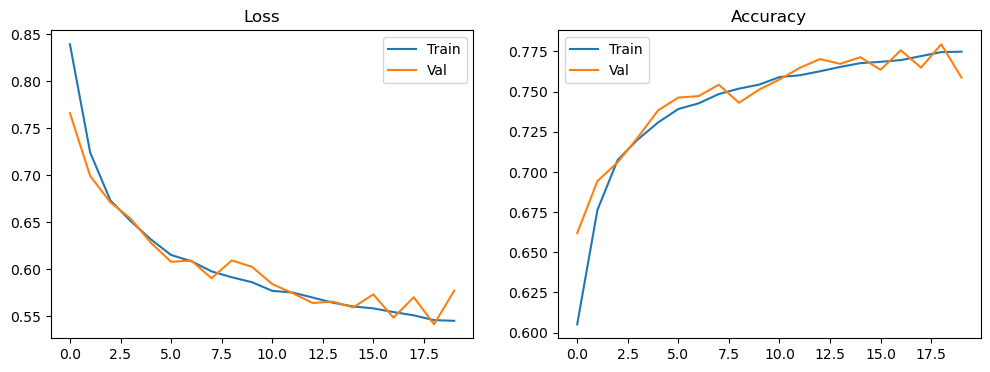

In [16]:

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend()
plt.title("Accuracy")

plt.show()


## 10. Visualize Predictions

In [17]:
def create_mask(pred_mask):
  pred_mask = tf.argmax(pred_mask, axis=-1)
  pred_mask = pred_mask[..., tf.newaxis]
  return pred_mask[0]

def show_predictions(dataset=None, num=1):
  if dataset:
    for image, mask in dataset.take(num):
      pred_mask = unet_model.predict(image)
      display([image[0], mask[0], create_mask(pred_mask)])
  else:
    display([sample_image, sample_mask,
             create_mask(model.predict(sample_image[tf.newaxis, ...]))])

In [18]:
count = 0
for i in test_batches:
    count +=1
print("number of batches:", count)

number of batches: 42


1/1 [==============================] - 0s 80ms/step


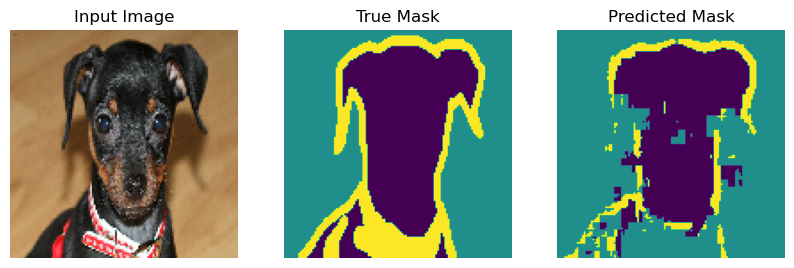

1/1 [==============================] - 0s 24ms/step


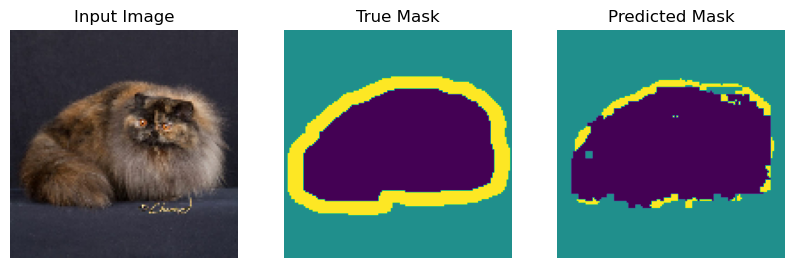

1/1 [==============================] - 0s 24ms/step


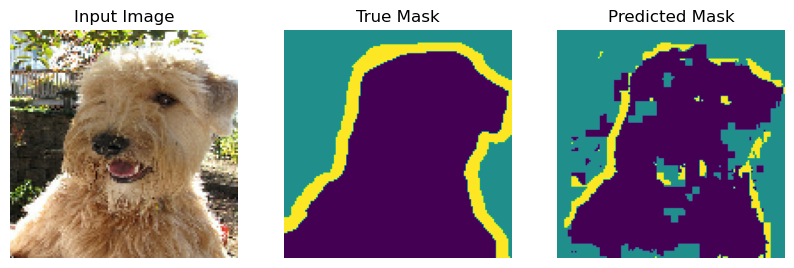

In [19]:
show_predictions(test_batches.skip(5), 3)

## 11. Tasks and questions


## Tasks

### T11.a) Try with more epochs, are 20 epochs sufficient?
To answer the question we will try to reinstate the model, this time with a much larger num_epoch, say 60. Then we will look for the built in early stop to be triggered, if it is triggered before 20 epochs then we can safely say that 20 was enough.

In [20]:
NUM_EPOCHS = 60

model_simple_epoch_test = simple_unet()

model_simple_epoch_test.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])


callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
]

history_epoch_test = model_simple_epoch_test.fit(
    train_batches,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    validation_data=validation_batches,
    epochs=NUM_EPOCHS,
    callbacks=callbacks
)


Epoch 1/60
230/230 [==============================] - 4s 15ms/step - loss: 0.8490 - accuracy: 0.6075 - val_loss: 0.7766 - val_accuracy: 0.6530
Epoch 2/60
230/230 [==============================] - 3s 14ms/step - loss: 0.7394 - accuracy: 0.6667 - val_loss: 0.7130 - val_accuracy: 0.6843
Epoch 3/60
230/230 [==============================] - 3s 14ms/step - loss: 0.6846 - accuracy: 0.7007 - val_loss: 0.6798 - val_accuracy: 0.7094
Epoch 4/60
230/230 [==============================] - 3s 14ms/step - loss: 0.6499 - accuracy: 0.7200 - val_loss: 0.6523 - val_accuracy: 0.7177
Epoch 5/60
230/230 [==============================] - 3s 14ms/step - loss: 0.6238 - accuracy: 0.7349 - val_loss: 0.6280 - val_accuracy: 0.7348
Epoch 6/60
230/230 [==============================] - 3s 14ms/step - loss: 0.6057 - accuracy: 0.7453 - val_loss: 0.5961 - val_accuracy: 0.7519
Epoch 7/60
230/230 [==============================] - 3s 14ms/step - loss: 0.5909 - accuracy: 0.7515 - val_loss: 0.5997 - val_accuracy: 0.7506

We see that the early stop is applied at epoch 33, then taking into account the patience of 5 epochs, the best result is about epoch 28, and so while 20 epochs is not far from the best, it would certainly make sense to use just a few more epochs to really hit our tolerance. We also see the validation accuracy really does not improve from epoch 28 and onwards. And so 20 epochs is close and 28 epochs is sufficient.

### T11.b) Study the large U-Net model and describe the differences from the simple U-Net model

The biggest difference between the large and simple U-net model is depth of the larger model. Where the simpel model only has two downsampling blocks before the bottleneck, whereas the larger model uses 4 downsampling blocks and gets to a bottleneck of 1024 filters, compared to the 128 of the simple model. On top of this the large model uses the double_conv_block function applying effectively two layers of the Conv2D at each step. Lastly the larger model uses dropouts to remain resiliant against overfitting and utilizes a kernel initializer which the simple model does not.

### T11.c) Select and add a method to measure performance such as accuracy for classification or MSE for regression
We choose to add the metric Mean IoU from chapter 14 of the book, as this is mentioned as the standard for Image Segmentation. First we need to conform the data from the softmax to integers which the MeanIoU expects:

In [ ]:

class MyMeanIoU(tf.keras.metrics.MeanIoU):
    def __init__(self, num_classes=3, name='mean_iou', **kwargs):
        super().__init__(num_classes=num_classes, name=name, **kwargs)

    def update_state(self, y_true, y_pred, sample_weight=None):
        # Step 1: Turn probabilities (Softmax) into class IDs (0, 1, or 2)
        y_pred = tf.math.argmax(y_pred, axis=-1)
        # Step 2: Call the original MeanIoU logic with the corrected shapes
        return super().update_state(y_true, y_pred, sample_weight)

model_simple_with_IoU = simple_unet()

# Now we can call the compiler
model_simple_with_IoU.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", MyMeanIoU(num_classes=3)]
)
# And then fit
model_simple_with_IoU.fit(train_batches, epochs=21, steps_per_epoch=STEPS_PER_EPOCH)



Epoch 1/21
230/230 [==============================] - 4s 13ms/step - loss: 0.8483 - accuracy: 0.6126 - mean_iou: 0.2726
Epoch 2/21
230/230 [==============================] - 3s 13ms/step - loss: 0.7354 - accuracy: 0.6691 - mean_iou: 0.3705
Epoch 3/21
230/230 [==============================] - 3s 13ms/step - loss: 0.6815 - accuracy: 0.7021 - mean_iou: 0.4244
Epoch 4/21
230/230 [==============================] - 3s 13ms/step - loss: 0.6512 - accuracy: 0.7186 - mean_iou: 0.4466
Epoch 5/21
230/230 [==============================] - 3s 13ms/step - loss: 0.6213 - accuracy: 0.7364 - mean_iou: 0.4702
Epoch 6/21
230/230 [==============================] - 3s 13ms/step - loss: 0.6188 - accuracy: 0.7373 - mean_iou: 0.4725
Epoch 7/21
230/230 [==============================] - 3s 13ms/step - loss: 0.5927 - accuracy: 0.7516 - mean_iou: 0.4916
Epoch 8/21
230/230 [==============================] - 3s 13ms/step - loss: 0.5863 - accuracy: 0.7539 - mean_iou: 0.4963
Epoch 9/21
230/230 [====================

In [22]:
test_results = model_simple_with_IoU.evaluate(test_batches)


print(f"Test Loss: {test_results[0]:.4f}")
print(f"Test Accuracy: {test_results[1]:.4f}")
print(f"Test Mean IoU: {test_results[2]:.4f}")
print("We see a mean IoU of about 0.53, which is not horrible but considering the range of IoU is 0 to 1 with the closer to 1 the better, we are not yet near pefection")

42/42 [==============================] - 1s 17ms/step - loss: 0.5347 - accuracy: 0.7785 - mean_iou: 0.5221
Test Loss: 0.5347
Test Accuracy: 0.7785
Test Mean IoU: 0.5221
We see a mean IoU of about 0.53, which is not horrible but considering the range of IoU is 0 to 1 with the closer to 1 the better, we are not yet near pefection


The reason IoU ranges from 0 to 1 is found in its formula, it is a fraction: 
$IoU = \frac{AreaOverlap}{AreaUnion}$

### T11.d) Compare the performance of the large U-Net with the simple U-Net model

Now we unleash the large U-net and compare with the simple using the same metrics.

In [23]:
NUM_EPOCHS = 20



# Comment line to use large U-Net model
# unet_model = model_simple

unet_model = build_unet_model()
unet_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", MyMeanIoU(num_classes=3)]
)

history = unet_model.fit(
    train_batches,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    validation_data=validation_batches,
    epochs=NUM_EPOCHS,
    callbacks=callbacks
)

Epoch 1/20


2026-04-28 09:22:26.528850: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inU-Net/dropout_8/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-04-28 09:22:27.786801: W external/local_tsl/tsl/framework/bfc_allocator.cc:366] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch sizes to observe the performance impact. Set TF_ENABLE_GPU_GARBAGE_COLLECTION=false if you'd like to disable this feature.


230/230 [==============================] - 57s 177ms/step - loss: 0.8233 - accuracy: 0.6322 - mean_iou: 0.3085 - val_loss: 0.6482 - val_accuracy: 0.7388 - val_mean_iou: 0.4545
Epoch 2/20
230/230 [==============================] - 38s 167ms/step - loss: 0.6170 - accuracy: 0.7534 - mean_iou: 0.4678 - val_loss: 0.5540 - val_accuracy: 0.7828 - val_mean_iou: 0.5266
Epoch 3/20
230/230 [==============================] - 38s 167ms/step - loss: 0.5258 - accuracy: 0.7957 - mean_iou: 0.5375 - val_loss: 0.4681 - val_accuracy: 0.8189 - val_mean_iou: 0.5763
Epoch 4/20
230/230 [==============================] - 38s 167ms/step - loss: 0.4716 - accuracy: 0.8189 - mean_iou: 0.5795 - val_loss: 0.4318 - val_accuracy: 0.8305 - val_mean_iou: 0.6094
Epoch 5/20
230/230 [==============================] - 38s 167ms/step - loss: 0.4344 - accuracy: 0.8337 - mean_iou: 0.6062 - val_loss: 0.4272 - val_accuracy: 0.8357 - val_mean_iou: 0.6209
Epoch 6/20
230/230 [==============================] - 39s 168ms/step - loss:

We see that in 15 epochs, that is where the earlystop got involved, the validation mean IoU is at 0.6757, which is significantly better than the simple model, and with only a 0.02 discrepancy between train and test IoU, we do not seem to have caused any overfitting with our big model. Then it is up to the engineer or company to descide if the 6x in training time is worth it. It is clear that the larger model performs significantly more accurate. 

### T11.e) Compare performance at different input resolutions (Simple U-Net model)

In [44]:
IMG_SIZE = 64

train_dataset = dataset["train"].map(load_image_train, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = dataset["test"].map(load_image_test, num_parallel_calls=tf.data.AUTOTUNE)

print(train_dataset)

<_ParallelMapDataset element_spec=(TensorSpec(shape=(64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(64, 64, 1), dtype=tf.uint8, name=None))>


In [45]:
model_res_test_64 = simple_unet() 

model_res_test_64.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", MyMeanIoU(num_classes=3)]
)

history = model_res_test_64.fit(
    train_batches,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    validation_data=validation_batches,
    epochs=NUM_EPOCHS,
    callbacks=callbacks
)

Epoch 1/20
230/230 [==============================] - 5s 15ms/step - loss: 0.8300 - accuracy: 0.6212 - mean_iou: 0.2877 - val_loss: 0.7473 - val_accuracy: 0.6682 - val_mean_iou: 0.3857
Epoch 2/20
230/230 [==============================] - 3s 15ms/step - loss: 0.7056 - accuracy: 0.6880 - mean_iou: 0.4004 - val_loss: 0.7400 - val_accuracy: 0.6675 - val_mean_iou: 0.3670
Epoch 3/20
230/230 [==============================] - 3s 15ms/step - loss: 0.6652 - accuracy: 0.7120 - mean_iou: 0.4355 - val_loss: 0.6507 - val_accuracy: 0.7208 - val_mean_iou: 0.4393
Epoch 4/20
230/230 [==============================] - 3s 15ms/step - loss: 0.6349 - accuracy: 0.7300 - mean_iou: 0.4595 - val_loss: 0.6178 - val_accuracy: 0.7393 - val_mean_iou: 0.4783
Epoch 5/20
230/230 [==============================] - 3s 15ms/step - loss: 0.6252 - accuracy: 0.7335 - mean_iou: 0.4662 - val_loss: 0.6366 - val_accuracy: 0.7278 - val_mean_iou: 0.4636
Epoch 6/20
230/230 [==============================] - 3s 15ms/step - loss: 

In [46]:
IMG_SIZE = 32

train_dataset = dataset["train"].map(load_image_train, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = dataset["test"].map(load_image_test, num_parallel_calls=tf.data.AUTOTUNE)

print(train_dataset)

<_ParallelMapDataset element_spec=(TensorSpec(shape=(32, 32, 3), dtype=tf.float32, name=None), TensorSpec(shape=(32, 32, 1), dtype=tf.uint8, name=None))>


In [47]:
model_res_test_32 = simple_unet() 

model_res_test_32.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", MyMeanIoU(num_classes=3)]
)

history = model_res_test_32.fit(
    train_batches,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    validation_data=validation_batches,
    epochs=NUM_EPOCHS,
    callbacks=callbacks
)

Epoch 1/20
230/230 [==============================] - 5s 15ms/step - loss: 0.8414 - accuracy: 0.6129 - mean_iou: 0.2788 - val_loss: 0.7635 - val_accuracy: 0.6437 - val_mean_iou: 0.3451
Epoch 2/20
230/230 [==============================] - 3s 14ms/step - loss: 0.7193 - accuracy: 0.6809 - mean_iou: 0.3895 - val_loss: 0.7004 - val_accuracy: 0.7019 - val_mean_iou: 0.4128
Epoch 3/20
230/230 [==============================] - 3s 14ms/step - loss: 0.6744 - accuracy: 0.7065 - mean_iou: 0.4315 - val_loss: 0.6501 - val_accuracy: 0.7248 - val_mean_iou: 0.4449
Epoch 4/20
230/230 [==============================] - 3s 14ms/step - loss: 0.6482 - accuracy: 0.7205 - mean_iou: 0.4501 - val_loss: 0.6395 - val_accuracy: 0.7282 - val_mean_iou: 0.4689
Epoch 5/20
230/230 [==============================] - 3s 15ms/step - loss: 0.6283 - accuracy: 0.7320 - mean_iou: 0.4655 - val_loss: 0.6081 - val_accuracy: 0.7496 - val_mean_iou: 0.5078
Epoch 6/20
230/230 [==============================] - 3s 14ms/step - loss: 

The validation accuracy really does not seem to be impacted by the lower resolutions, this might be because it is already the "shallowness" of our simple model, that caps the accuracy, furthermore the dataset we are working on does not require attention to very fine details like the hairs on a cat, so even at 32x32 resolution the model is somewhat able to determine where the pet is and where the background is. It could be fun to look into with the larger model and see if it impacts the predictions near the border, where the larger model seems more delicate than the simpler model.

## Questions

### Q11.a) How does segmentation differ from classification?
Classification is a bit more big picture oriented, meaning a classifier will focus on saying that is a dog (or cat or whatever), sometimes as simple as true or false. Segmentation on the other hand will try to draw a border of pixels outlining where in the picture the dog is. This is however also quite a task to perform and as we saw above can require a lot of time to get good results.

### Q11.b) What data augmentation is used and where?
We can see the augemtation happening in the preprocessing part, more specifically the lines around
"def augment(input_image, input_mask):        
Where we flip the pictures to ensure that the model does not learn general placements of the pets. But learns to look for pets wherever they might be. It is worth noting that we do not flip the test data, since we should avoid fiddling with that in most cases.


### Q11.b) What is the purpose of skip connections?
Skip connections, skip, some of the deepest layers and passes information on to the decoders, this is done as an attempt to recover some of spatial resolution, that might be lost otherwise when scaling all the way down to the bottleneck, where much less data is stored. 

### Deliverables:

- Completed notebook with experiments
- Plots and answers to questions
- Short written reflection on results

REVISIONS||
:- | :-
2022-01-23| KBE, initial. 
2026-03-19| KBE, updated task T11.c 
2026-03-19| KBE, added ['metrics']